Mounted at /content/drive
✅ Libraries loaded
✅ Config loaded
   Datasets         : 11
   Train/Test       : 70% / 30%
   NB variants      : ['GaussianNB', 'ComplementNB', 'BernoulliNB']
   Class prior      : [0.6, 0.4]  [neg, pos]
   var_smoothing    : sweep [1e-09, 1e-07, 1e-05, 0.001, 0.1]
  Naive Bayes — Variant Comparison per Dataset

  AAC        → GaussianNB:0.569  ComplementNB:0.551  BernoulliNB:0.526
             Best variant = GaussianNB  (AUC=0.5691)

  DPC        → GaussianNB:0.551  ComplementNB:0.560  BernoulliNB:0.768
             Best variant = BernoulliNB  (AUC=0.7682)

  CTDC       → GaussianNB:0.520  ComplementNB:0.511  BernoulliNB:0.569
             Best variant = BernoulliNB  (AUC=0.5694)

  CTDT       → GaussianNB:0.548  ComplementNB:0.513  BernoulliNB:0.538
             Best variant = GaussianNB  (AUC=0.5479)

  GAAC       → GaussianNB:0.517  ComplementNB:0.516  BernoulliNB:0.520
             Best variant = BernoulliNB  (AUC=0.5204)

  PAAC       → GaussianNB:0.569

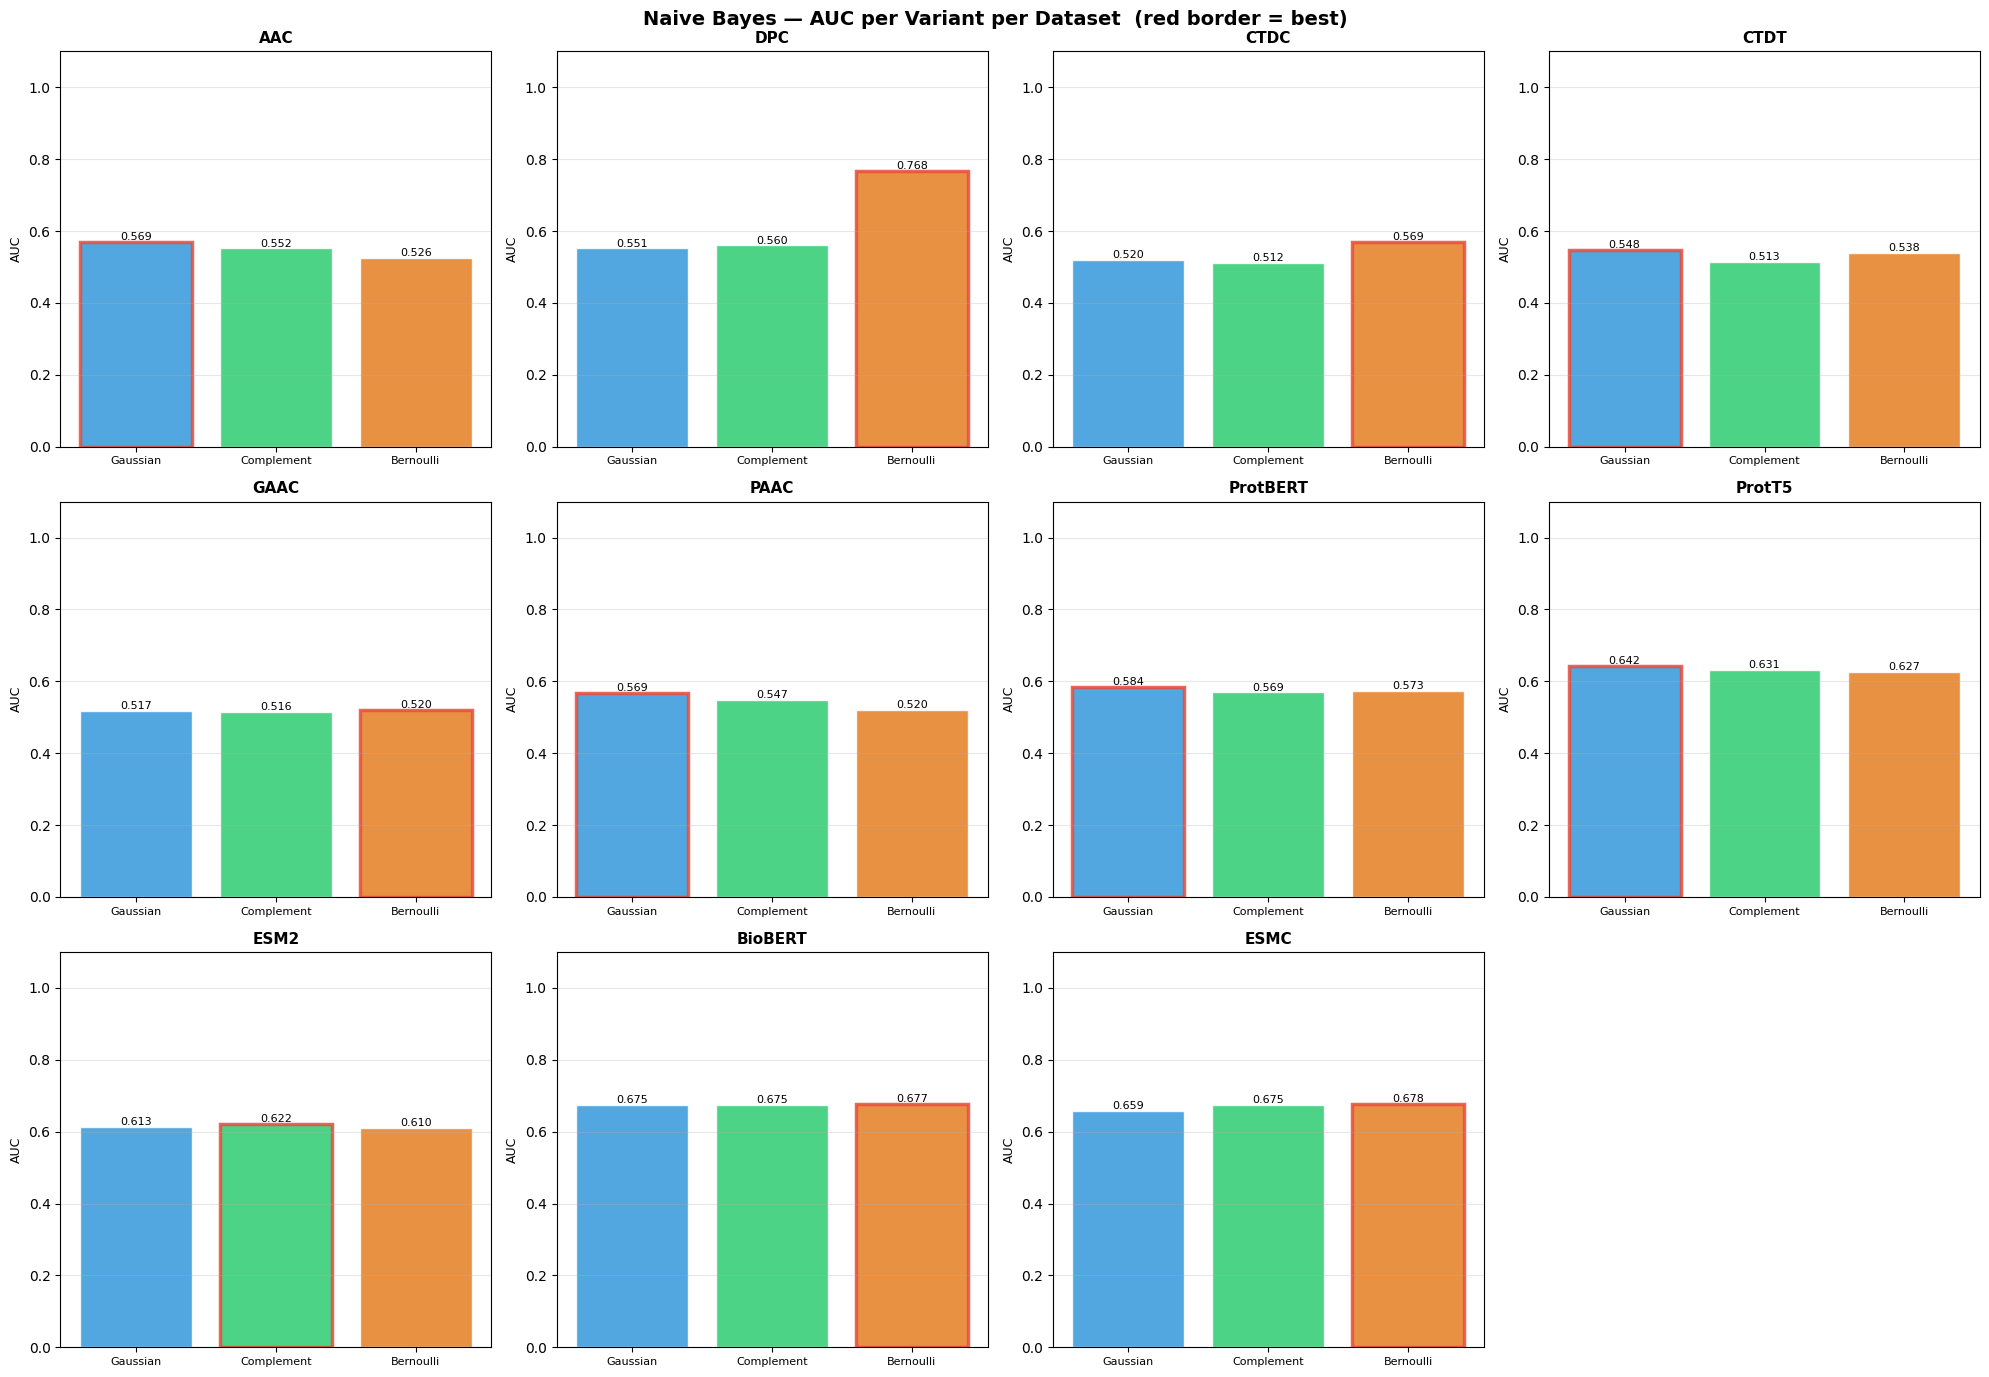

✅ Variant comparison plot saved
  Naive Bayes — var_smoothing Sensitivity (GaussianNB datasets)

  AAC        → 1e-09:0.569  1e-07:0.569  1e-05:0.569  1e-03:0.569  1e-01:0.569
             Best var_smoothing = 1e-09  (AUC=0.5691)

  CTDT       → 1e-09:0.548  1e-07:0.548  1e-05:0.548  1e-03:0.548  1e-01:0.546
             Best var_smoothing = 1e-09  (AUC=0.5479)

  PAAC       → 1e-09:0.569  1e-07:0.569  1e-05:0.569  1e-03:0.569  1e-01:0.567
             Best var_smoothing = 1e-09  (AUC=0.5687)

  ProtBERT   → 1e-09:0.584  1e-07:0.584  1e-05:0.584  1e-03:0.584  1e-01:0.583
             Best var_smoothing = 1e-09  (AUC=0.5840)

  ProtT5     → 1e-09:0.642  1e-07:0.642  1e-05:0.642  1e-03:0.642  1e-01:0.642
             Best var_smoothing = 1e-09  (AUC=0.6425)

✅ var_smoothing analysis complete
  Naive Bayes — Training & Evaluation on 11 Datasets

────────────────────────────────────────────────────────────
  Dataset : AAC  (AAC_features.csv)
  Shape   : (2190, 21)  |  Features: 20  |  Pos:

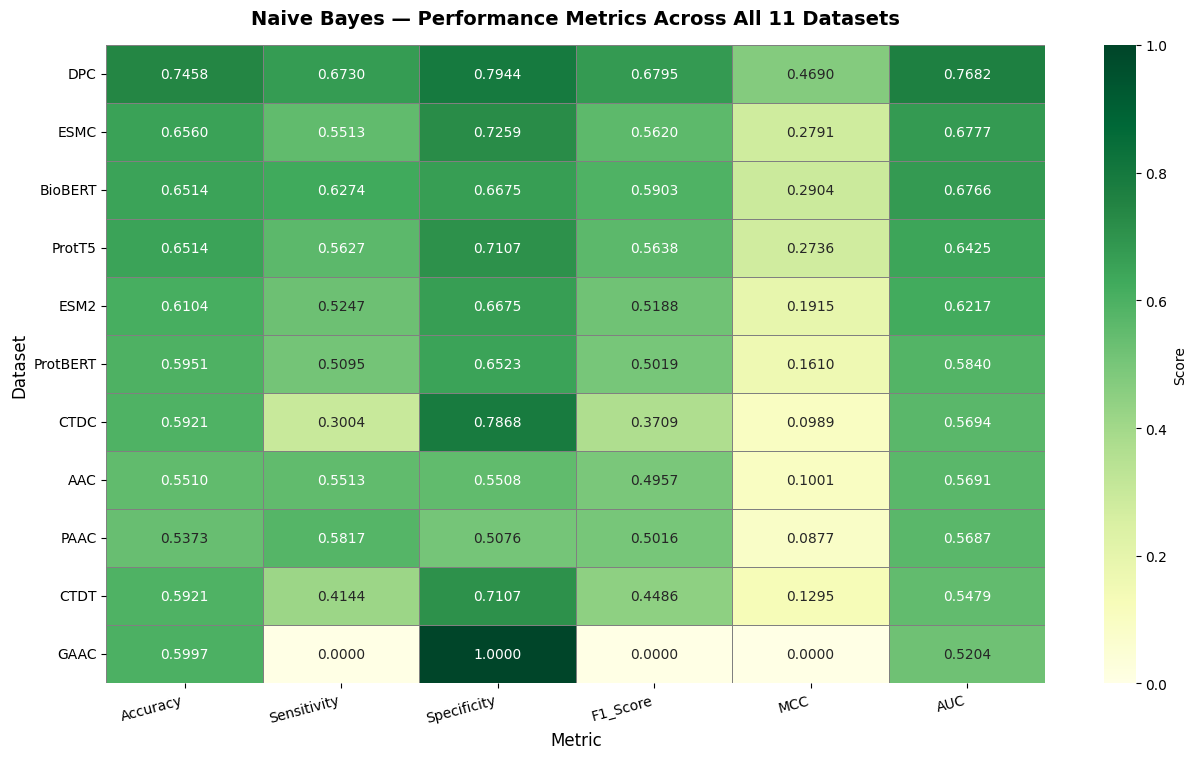

✅ Metrics heatmap saved


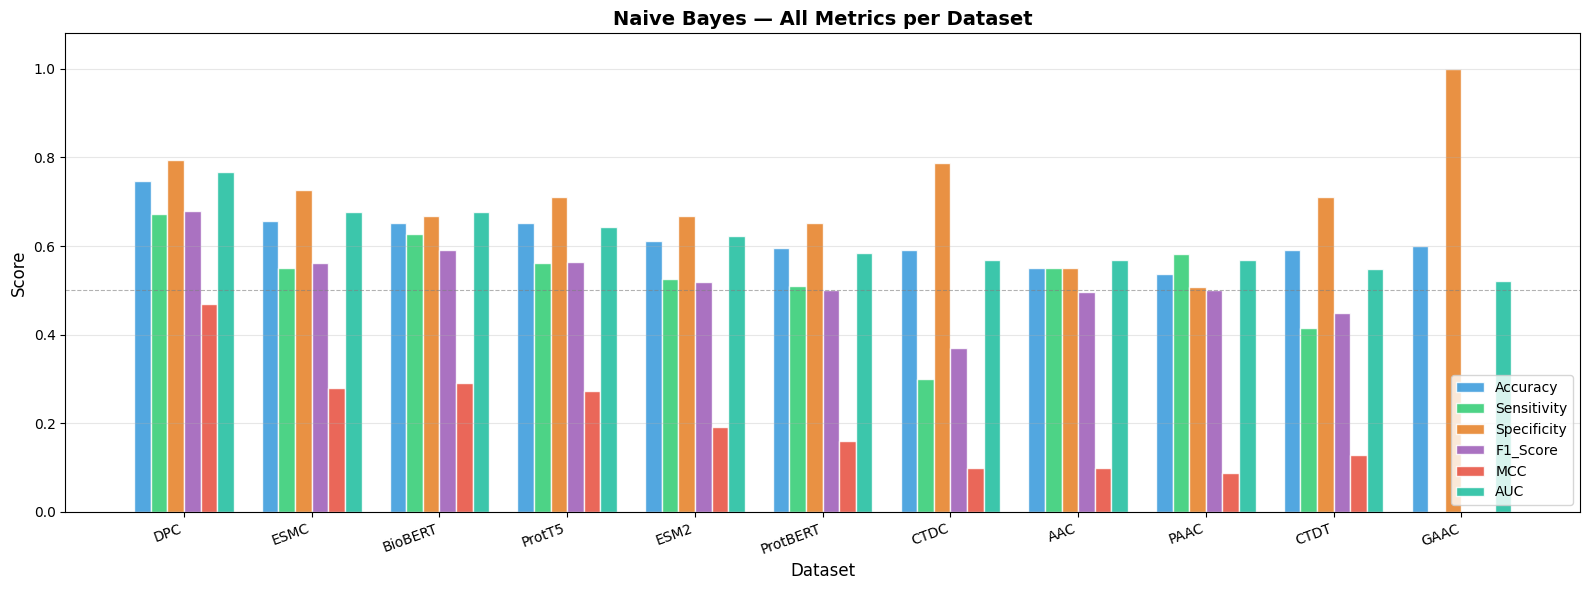

✅ Grouped bar chart saved


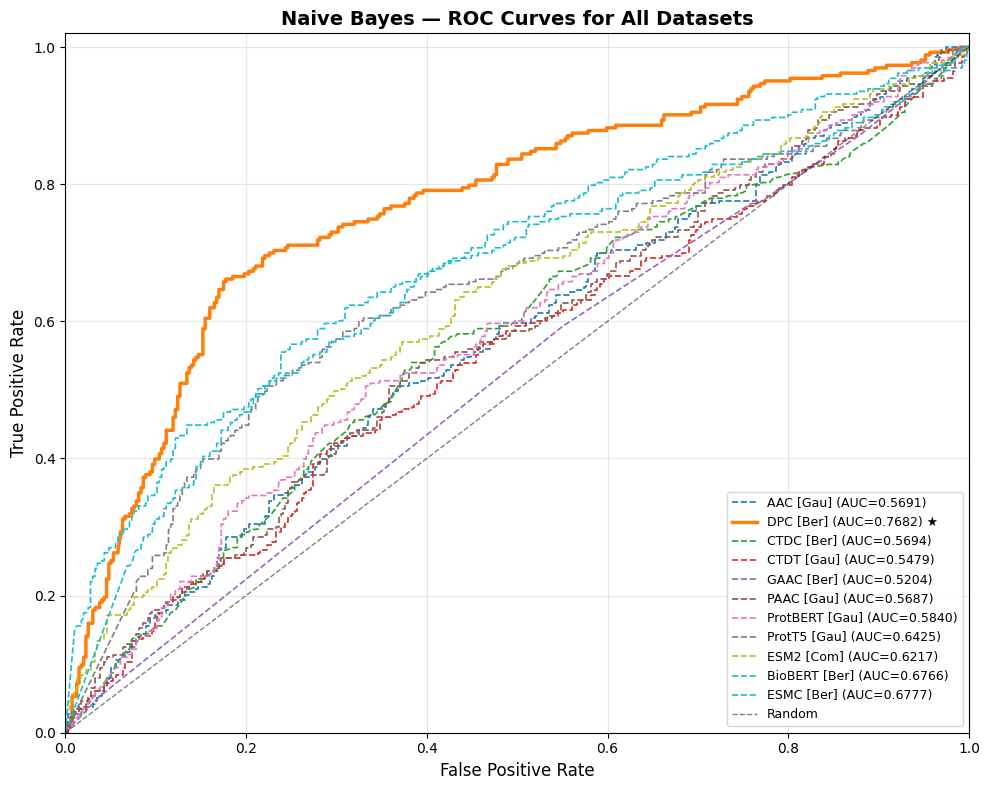

✅ ROC curves saved


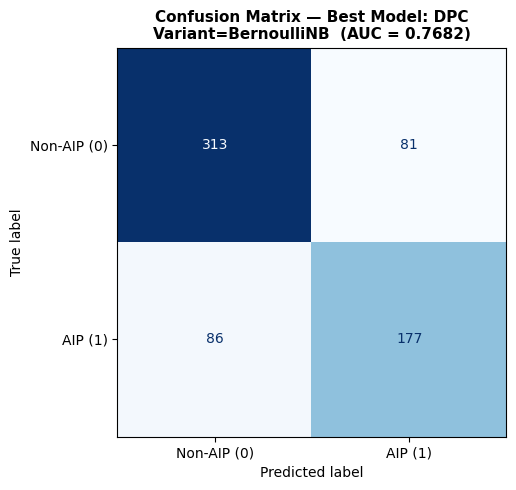

✅ Confusion matrix saved (DPC)


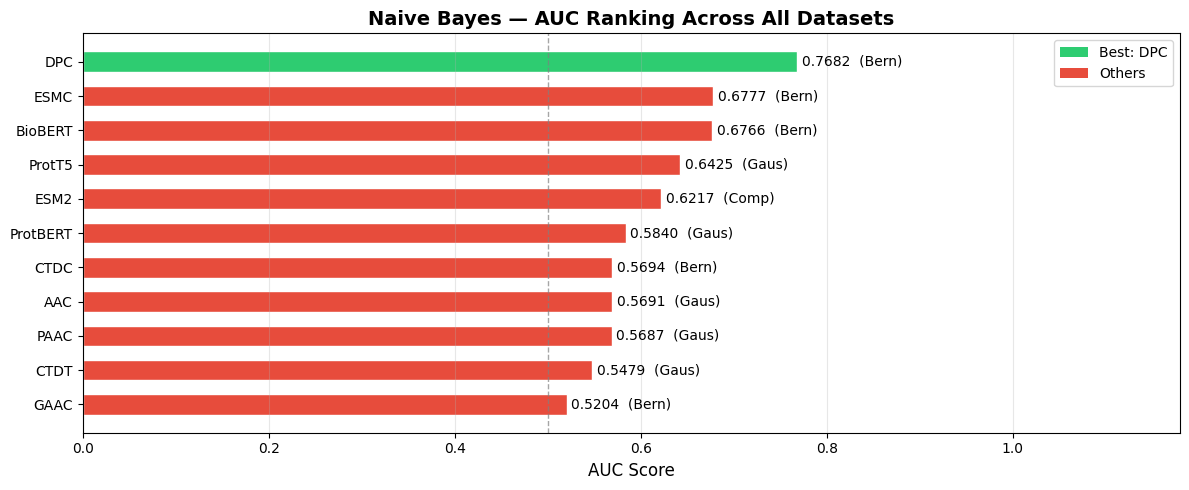

✅ AUC ranking chart saved
ℹ️  Best variant is BernoulliNB — distribution plot only available for GaussianNB
  NAIVE BAYES — FINAL SUMMARY

  Results saved to  : /content/drive/MyDrive/Colab Notebooks/AIP Prediction/results/naive_bayes
  Figures saved to  : /content/drive/MyDrive/Colab Notebooks/AIP Prediction/results/figures/naive_bayes
  Model saved to    : /content/drive/MyDrive/Colab Notebooks/AIP Prediction/models/naive_bayes

─────────────────────────────────────────────────────────────────
  Dataset      Variant             Acc       Sn       Sp       F1      MCC      AUC
─────────────────────────────────────────────────────────────────
  DPC          BernoulliNB      0.7458   0.6730   0.7944   0.6795   0.4690   0.7682 ★
  ESMC         BernoulliNB      0.6560   0.5513   0.7259   0.5620   0.2791   0.6777
  BioBERT      BernoulliNB      0.6514   0.6274   0.6675   0.5903   0.2904   0.6766
  ProtT5       GaussianNB       0.6514   0.5627   0.7107   0.5638   0.2736   0.6425
  ESM2     

In [1]:
# ============================================================
#   CELL 1 — Mount Google Drive
# ============================================================
from google.colab import drive
drive.mount('/content/drive')


# ============================================================
#   CELL 2 — Install & Import Libraries
# ============================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings("ignore")

from sklearn.naive_bayes import GaussianNB, ComplementNB, BernoulliNB
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import (
    accuracy_score, f1_score, matthews_corrcoef,
    confusion_matrix, roc_auc_score, roc_curve,
    ConfusionMatrixDisplay
)

print("✅ Libraries loaded")


# ============================================================
#   CELL 3 — Configuration
# ============================================================

FEATURE_DIR  = "/content/drive/MyDrive/Colab Notebooks/AIP Prediction/data/features"
RESULTS_DIR  = "/content/drive/MyDrive/Colab Notebooks/AIP Prediction/results/naive_bayes"
FIGURES_DIR  = "/content/drive/MyDrive/Colab Notebooks/AIP Prediction/results/figures/naive_bayes"
MODELS_DIR   = "/content/drive/MyDrive/Colab Notebooks/AIP Prediction/models/naive_bayes"

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(MODELS_DIR,  exist_ok=True)

# ── All 11 feature datasets ──────────────────────────────────
DATASETS = {
    "AAC"     : "AAC_features.csv",
    "DPC"     : "DPC_features.csv",
    "CTDC"    : "CTDC_features.csv",
    "CTDT"    : "CTDT_features.csv",
    "GAAC"    : "GAAC_features.csv",
    "PAAC"    : "PAAC_features.csv",
    "ProtBERT": "ProtBERT_features.csv",
    "ProtT5"  : "ProtT5_features.csv",
    "ESM2"    : "ESM2_features.csv",
    "BioBERT" : "BioBERT_features.csv",
    "ESMC"    : "ESMC_features.csv",
}

# ── Naive Bayes variants overview ────────────────────────────
#
#  Naive Bayes assumes features are conditionally independent
#  given the class label. Despite this strong assumption, it
#  often performs well in practice and is the fastest of all
#  classifiers.
#
#  Variants used:
#    GaussianNB    — assumes each feature follows a Gaussian
#                    (Normal) distribution per class ✅ default
#                    suitable for continuous features (all datasets)
#                    var_smoothing: adds small variance to avoid
#                    zero-probability for unseen feature values
#
#    ComplementNB  — uses complement class statistics
#                    more robust than GaussianNB for imbalanced data
#                    requires non-negative features → MinMaxScaler
#
#    BernoulliNB   — models binary feature presence/absence
#                    useful for DPC/AAC (mostly sparse features)
#                    binarizes features at threshold (default 0.0)
#                    requires non-negative features → MinMaxScaler
#
#  Class imbalance:
#    GaussianNB uses class_prior to correct for 1:1.5 imbalance
#    class_prior = [neg_fraction, pos_fraction]
#    for 876 pos / 1314 neg out of 2190:
#      pos fraction = 876/2190 ≈ 0.40
#      neg fraction = 1314/2190 ≈ 0.60
#
NB_VARIANTS = ["GaussianNB", "ComplementNB", "BernoulliNB"]

# GaussianNB parameters
GNB_VAR_SMOOTHING_VALUES = [1e-9, 1e-7, 1e-5, 1e-3, 1e-1]

# Class prior to handle 1:1.5 imbalance
# Recomputed per dataset in the loop
CLASS_PRIOR_DEFAULT = [0.60, 0.40]   # [neg, pos]

TEST_SIZE    = 0.30
RANDOM_STATE = 42

print(f"✅ Config loaded")
print(f"   Datasets         : {len(DATASETS)}")
print(f"   Train/Test       : {int((1-TEST_SIZE)*100)}% / {int(TEST_SIZE*100)}%")
print(f"   NB variants      : {NB_VARIANTS}")
print(f"   Class prior      : {CLASS_PRIOR_DEFAULT}  [neg, pos]")
print(f"   var_smoothing    : sweep {GNB_VAR_SMOOTHING_VALUES}")


# ============================================================
#   CELL 4 — Metric Helper Functions
# ============================================================

def compute_metrics(y_true, y_pred, y_prob):
    """
    Compute all 6 performance metrics.

    Metrics:
      Accuracy    = (TP + TN) / (TP + TN + FP + FN)
      Sensitivity = TP / (TP + FN)   [Recall for positive class]
      Specificity = TN / (TN + FP)   [Recall for negative class]
      F1 Score    = 2 × (Precision × Recall) / (Precision + Recall)
      MCC         = Matthews Correlation Coefficient
      AUC         = Area Under ROC Curve
    """
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    accuracy    = accuracy_score(y_true, y_pred)
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    f1          = f1_score(y_true, y_pred, zero_division=0)
    mcc         = matthews_corrcoef(y_true, y_pred)
    auc         = roc_auc_score(y_true, y_prob)

    return {
        "Accuracy"   : round(accuracy,    4),
        "Sensitivity": round(sensitivity, 4),
        "Specificity": round(specificity, 4),
        "F1_Score"   : round(f1,          4),
        "MCC"        : round(mcc,         4),
        "AUC"        : round(auc,         4),
        "TP": int(tp), "TN": int(tn),
        "FP": int(fp), "FN": int(fn),
    }


def load_dataset(csv_path):
    """
    Load a feature CSV, auto-detect feature columns and label.
    Expects: seq_id column, feature columns, label column (last).
    """
    df = pd.read_csv(csv_path)

    drop_cols = [c for c in ["seq_id", "sequence", "length"]
                 if c in df.columns]
    df = df.drop(columns=drop_cols)

    X = df.iloc[:, :-1].values
    y = df.iloc[:, -1].values.astype(int)

    return X, y, df.columns[-1], df.shape


def get_class_prior(y_train):
    """
    Compute class prior from training labels to handle imbalance.
    Returns [neg_fraction, pos_fraction].
    """
    n_total = len(y_train)
    n_pos   = y_train.sum()
    n_neg   = n_total - n_pos
    return [round(n_neg / n_total, 4), round(n_pos / n_total, 4)]


# ============================================================
#   CELL 5 — Variant Comparison per Dataset
#            Compares GaussianNB, ComplementNB, BernoulliNB
#            to find best variant per dataset
# ============================================================

print("=" * 65)
print("  Naive Bayes — Variant Comparison per Dataset")
print("=" * 65)

best_variant_per_ds = {}

for ds_name, csv_file in DATASETS.items():

    csv_path = os.path.join(FEATURE_DIR, csv_file)
    if not os.path.exists(csv_path):
        continue

    X, y, _, _ = load_dataset(csv_path)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE,
        random_state=RANDOM_STATE, stratify=y
    )

    # StandardScaler for GaussianNB
    std_scaler  = StandardScaler()
    X_train_std = std_scaler.fit_transform(X_train)
    X_test_std  = std_scaler.transform(X_test)

    # MinMaxScaler for ComplementNB and BernoulliNB
    # (require non-negative features)
    mm_scaler   = MinMaxScaler()
    X_train_mm  = mm_scaler.fit_transform(X_train)
    X_test_mm   = mm_scaler.transform(X_test)

    class_prior = get_class_prior(y_train)
    variant_aucs = {}

    # GaussianNB
    gnb = GaussianNB(var_smoothing=1e-9,
                     priors=class_prior)
    gnb.fit(X_train_std, y_train)
    y_prob_gnb              = gnb.predict_proba(X_test_std)[:, 1]
    variant_aucs["GaussianNB"]  = round(
        roc_auc_score(y_test, y_prob_gnb), 4)

    # ComplementNB (needs non-negative)
    cnb = ComplementNB(alpha=1.0)
    cnb.fit(X_train_mm, y_train)
    y_prob_cnb              = cnb.predict_proba(X_test_mm)[:, 1]
    variant_aucs["ComplementNB"] = round(
        roc_auc_score(y_test, y_prob_cnb), 4)

    # BernoulliNB (needs non-negative)
    bnb = BernoulliNB(alpha=1.0, binarize=0.5)
    bnb.fit(X_train_mm, y_train)
    y_prob_bnb              = bnb.predict_proba(X_test_mm)[:, 1]
    variant_aucs["BernoulliNB"]  = round(
        roc_auc_score(y_test, y_prob_bnb), 4)

    best_variant                   = max(variant_aucs,
                                         key=variant_aucs.get)
    best_variant_per_ds[ds_name]   = best_variant

    v_str = "  ".join([f"{k}:{v:.3f}"
                        for k, v in variant_aucs.items()])
    print(f"\n  {ds_name:<10} → {v_str}")
    print(f"             Best variant = {best_variant}  "
          f"(AUC={variant_aucs[best_variant]:.4f})")

print(f"\n✅ Variant comparison complete")
print(f"   Best variant per dataset: {best_variant_per_ds}")


# ============================================================
#   CELL 6 — Variant Comparison Plot
# ============================================================

fig, axes = plt.subplots(3, 4, figsize=(20, 14), sharey=False)
axes = axes.flatten()

variant_colors = {
    "GaussianNB"  : "#3498db",
    "ComplementNB": "#2ecc71",
    "BernoulliNB" : "#e67e22",
}

for idx, (ds_name, csv_file) in enumerate(DATASETS.items()):

    csv_path = os.path.join(FEATURE_DIR, csv_file)
    if not os.path.exists(csv_path):
        axes[idx].set_visible(False)
        continue

    ax = axes[idx]
    X, y, _, _ = load_dataset(csv_path)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE,
        random_state=RANDOM_STATE, stratify=y
    )

    std_scaler  = StandardScaler()
    X_train_std = std_scaler.fit_transform(X_train)
    X_test_std  = std_scaler.transform(X_test)

    mm_scaler   = MinMaxScaler()
    X_train_mm  = mm_scaler.fit_transform(X_train)
    X_test_mm   = mm_scaler.transform(X_test)

    class_prior = get_class_prior(y_train)

    aucs = []
    for variant in NB_VARIANTS:
        if variant == "GaussianNB":
            clf = GaussianNB(var_smoothing=1e-9,
                             priors=class_prior)
            clf.fit(X_train_std, y_train)
            y_prob = clf.predict_proba(X_test_std)[:, 1]
        elif variant == "ComplementNB":
            clf = ComplementNB(alpha=1.0)
            clf.fit(X_train_mm, y_train)
            y_prob = clf.predict_proba(X_test_mm)[:, 1]
        else:
            clf = BernoulliNB(alpha=1.0, binarize=0.5)
            clf.fit(X_train_mm, y_train)
            y_prob = clf.predict_proba(X_test_mm)[:, 1]
        aucs.append(roc_auc_score(y_test, y_prob))

    best_v   = best_variant_per_ds.get(ds_name, "GaussianNB")
    best_idx = NB_VARIANTS.index(best_v)

    bars = ax.bar(
        NB_VARIANTS, aucs,
        color=[variant_colors[v] for v in NB_VARIANTS],
        edgecolor="white", alpha=0.85
    )
    bars[best_idx].set_edgecolor("#e74c3c")
    bars[best_idx].set_linewidth(2.5)

    for bar, val in zip(bars, aucs):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f"{val:.3f}", ha="center", fontsize=8)

    ax.set_title(ds_name, fontsize=11, fontweight="bold")
    ax.set_ylabel("AUC", fontsize=9)
    ax.set_ylim(0, 1.1)
    ax.set_xticklabels(["Gaussian", "Complement", "Bernoulli"],
                       fontsize=8)
    ax.grid(axis="y", alpha=0.3)

for idx in range(len(DATASETS), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle(
    "Naive Bayes — AUC per Variant per Dataset  (red border = best)",
    fontsize=14, fontweight="bold"
)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "NB_variant_comparison.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Variant comparison plot saved")


# ============================================================
#   CELL 7 — var_smoothing Sensitivity (GaussianNB only)
#            Only applied for datasets where best variant
#            is GaussianNB — sweeps [1e-9, 1e-7, 1e-5, 1e-3, 1e-1]
# ============================================================

print("=" * 65)
print("  Naive Bayes — var_smoothing Sensitivity (GaussianNB datasets)")
print("=" * 65)

best_smoothing_per_ds = {}

for ds_name, csv_file in DATASETS.items():

    csv_path = os.path.join(FEATURE_DIR, csv_file)
    if not os.path.exists(csv_path):
        continue

    best_v = best_variant_per_ds.get(ds_name, "GaussianNB")

    # Only sweep smoothing for GaussianNB datasets
    if best_v != "GaussianNB":
        best_smoothing_per_ds[ds_name] = 1e-9   # default, not used
        continue

    X, y, _, _ = load_dataset(csv_path)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE,
        random_state=RANDOM_STATE, stratify=y
    )

    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    class_prior = get_class_prior(y_train)
    smooth_aucs = {}

    for vs in GNB_VAR_SMOOTHING_VALUES:
        gnb = GaussianNB(var_smoothing=vs, priors=class_prior)
        gnb.fit(X_train, y_train)
        y_prob_vs    = gnb.predict_proba(X_test)[:, 1]
        smooth_aucs[vs] = round(roc_auc_score(y_test, y_prob_vs), 4)

    best_vs                      = max(smooth_aucs,
                                        key=smooth_aucs.get)
    best_smoothing_per_ds[ds_name] = best_vs

    vs_str = "  ".join([f"{k:.0e}:{v:.3f}"
                         for k, v in smooth_aucs.items()])
    print(f"\n  {ds_name:<10} → {vs_str}")
    print(f"             Best var_smoothing = {best_vs:.0e}  "
          f"(AUC={smooth_aucs[best_vs]:.4f})")

print(f"\n✅ var_smoothing analysis complete")


# ============================================================
#   CELL 8 — Main Training Loop
#            Uses best variant + best var_smoothing per dataset
# ============================================================

all_results  = []
best_model   = None
best_scaler  = None
best_name    = ""
best_auc     = -1.0
all_probs    = {}

print("=" * 65)
print("  Naive Bayes — Training & Evaluation on 11 Datasets")
print("=" * 65)

for ds_name, csv_file in DATASETS.items():

    csv_path = os.path.join(FEATURE_DIR, csv_file)

    if not os.path.exists(csv_path):
        print(f"\n⏭  [{ds_name}] File not found — skipping: {csv_file}")
        continue

    print(f"\n{'─'*60}")
    print(f"  Dataset : {ds_name}  ({csv_file})")

    # ── Load & split ─────────────────────────────────────────
    X, y, label_col, shape = load_dataset(csv_path)
    print(f"  Shape   : {shape}  |  Features: {X.shape[1]}  |  "
          f"Pos: {y.sum()}  Neg: {(y==0).sum()}")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size    = TEST_SIZE,
        random_state = RANDOM_STATE,
        stratify     = y
    )

    print(f"  Train   : {len(X_train)} samples  |  "
          f"Test: {len(X_test)} samples")

    # ── Select best variant and scaler ───────────────────────
    variant_used = best_variant_per_ds.get(ds_name, "GaussianNB")
    class_prior  = get_class_prior(y_train)

    # GaussianNB → StandardScaler
    # ComplementNB / BernoulliNB → MinMaxScaler (non-negative required)
    if variant_used == "GaussianNB":
        scaler  = StandardScaler()
    else:
        scaler  = MinMaxScaler()

    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    print(f"  Variant : {variant_used}  |  "
          f"Scaler: {'StandardScaler' if variant_used == 'GaussianNB' else 'MinMaxScaler'}  |  "
          f"Prior: {class_prior}")

    # ── Build classifier ─────────────────────────────────────
    if variant_used == "GaussianNB":
        vs_used = best_smoothing_per_ds.get(ds_name, 1e-9)
        clf = GaussianNB(
            var_smoothing = vs_used,
            priors        = class_prior,
        )
        print(f"  var_smoothing : {vs_used:.0e}")

    elif variant_used == "ComplementNB":
        vs_used = None
        clf = ComplementNB(alpha=1.0)

    else:   # BernoulliNB
        vs_used = None
        clf = BernoulliNB(alpha=1.0, binarize=0.5)

    # ── Train ────────────────────────────────────────────────
    clf.fit(X_train, y_train)

    # ── Predict ──────────────────────────────────────────────
    y_pred = clf.predict(X_test)
    y_prob = clf.predict_proba(X_test)[:, 1]

    # ── Metrics ──────────────────────────────────────────────
    metrics = compute_metrics(y_test, y_pred, y_prob)
    metrics["Dataset"]      = ds_name
    metrics["Features"]     = X.shape[1]
    metrics["Variant_used"] = variant_used
    metrics["Var_smoothing"]= vs_used if vs_used else "N/A"
    metrics["Train_N"]      = len(X_train)
    metrics["Test_N"]       = len(X_test)
    all_results.append(metrics)

    print(f"\n  ── Results ──────────────────────────────────────")
    print(f"  Accuracy    : {metrics['Accuracy']:.4f}")
    print(f"  Sensitivity : {metrics['Sensitivity']:.4f}")
    print(f"  Specificity : {metrics['Specificity']:.4f}")
    print(f"  F1 Score    : {metrics['F1_Score']:.4f}")
    print(f"  MCC         : {metrics['MCC']:.4f}")
    print(f"  AUC         : {metrics['AUC']:.4f}")
    print(f"  TP={metrics['TP']}  TN={metrics['TN']}  "
          f"FP={metrics['FP']}  FN={metrics['FN']}")

    # ── Save probabilities ───────────────────────────────────
    df_probs = pd.DataFrame({
        "y_true"       : y_test,
        "y_pred"       : y_pred,
        "prob_positive": y_prob,
        "prob_negative": 1 - y_prob,
    })
    prob_path = os.path.join(RESULTS_DIR,
                             f"{ds_name}_NB_probabilities.csv")
    df_probs.to_csv(prob_path, index=False)

    all_probs[ds_name] = {
        "y_test" : y_test,
        "y_pred" : y_pred,
        "y_prob" : y_prob,
        "clf"    : clf,
        "scaler" : scaler,
        "variant": variant_used,
    }

    # ── Track best model ─────────────────────────────────────
    if metrics["AUC"] > best_auc:
        best_auc    = metrics["AUC"]
        best_name   = ds_name
        best_model  = clf
        best_scaler = scaler

    print(f"  Probabilities saved → {prob_path}")

print(f"\n{'='*65}")
print(f"  ✅ Training complete for {len(all_results)} datasets")
print(f"  🏆 Best model: {best_name}  (AUC = {best_auc:.4f})")
print(f"{'='*65}")


# ============================================================
#   CELL 9 — Results Summary Table
# ============================================================

metric_cols = ["Dataset", "Variant_used", "Var_smoothing",
               "Accuracy", "Sensitivity", "Specificity",
               "F1_Score", "MCC", "AUC", "Features"]

df_results = pd.DataFrame(all_results)[metric_cols].sort_values(
    "AUC", ascending=False
).reset_index(drop=True)

df_results.index += 1

print("\n── Naive Bayes Performance Summary (sorted by AUC) ──")
print(df_results.to_string())

summary_path = os.path.join(RESULTS_DIR, "NB_all_results_summary.csv")
df_results.to_csv(summary_path, index=True, index_label="Rank")
print(f"\n✅ Summary saved → {summary_path}")


# ============================================================
#   CELL 10 — Save Best Model
# ============================================================

best_model_path  = os.path.join(MODELS_DIR,
                                f"NB_best_model_{best_name}.joblib")
best_scaler_path = os.path.join(MODELS_DIR,
                                f"NB_best_scaler_{best_name}.joblib")

joblib.dump(best_model,  best_model_path)
joblib.dump(best_scaler, best_scaler_path)

print(f"✅ Best model saved")
print(f"   Dataset       : {best_name}")
print(f"   Variant       : {best_variant_per_ds.get(best_name)}")
print(f"   AUC           : {best_auc:.4f}")
print(f"   Model         : {best_model_path}")
print(f"   Scaler        : {best_scaler_path}")


# ============================================================
#   CELL 11 — Visualization 1: Metrics Heatmap (All Datasets)
# ============================================================

heat_cols = ["Accuracy", "Sensitivity", "Specificity",
             "F1_Score", "MCC", "AUC"]
heat_data = df_results.set_index("Dataset")[heat_cols]

fig, ax = plt.subplots(figsize=(13, max(5, len(heat_data) * 0.7)))

sns.heatmap(
    heat_data,
    annot     = True,
    fmt       = ".4f",
    cmap      = "YlGn",
    linewidths= 0.5,
    linecolor = "grey",
    vmin      = 0,
    vmax      = 1,
    ax        = ax,
    cbar_kws  = {"label": "Score"}
)

ax.set_title("Naive Bayes — Performance Metrics Across All 11 Datasets",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Metric", fontsize=12)
ax.set_ylabel("Dataset", fontsize=12)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=15,
                   ha="right", fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "NB_metrics_heatmap.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Metrics heatmap saved")


# ============================================================
#   CELL 12 — Visualization 2: Grouped Bar Chart (All Metrics)
# ============================================================

fig, ax = plt.subplots(figsize=(16, 6))

x      = np.arange(len(df_results))
width  = 0.13
colors = ["#3498db", "#2ecc71", "#e67e22", "#9b59b6", "#e74c3c", "#1abc9c"]

for i, (col, color) in enumerate(zip(heat_cols, colors)):
    offset = (i - len(heat_cols) / 2 + 0.5) * width
    ax.bar(x + offset, df_results[col].values,
           width, label=col, color=color,
           alpha=0.85, edgecolor="white")

ax.set_xlabel("Dataset", fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Naive Bayes — All Metrics per Dataset",
             fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(df_results["Dataset"],
                   rotation=20, ha="right", fontsize=10)
ax.set_ylim(0, 1.08)
ax.legend(fontsize=10, loc="lower right")
ax.grid(axis="y", alpha=0.3)
ax.axhline(0.5, color="grey", linestyle="--", linewidth=0.8, alpha=0.6)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "NB_grouped_bar_chart.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Grouped bar chart saved")


# ============================================================
#   CELL 13 — Visualization 3: ROC Curves (All Datasets)
# ============================================================

fig, ax = plt.subplots(figsize=(10, 8))

cmap   = plt.cm.get_cmap("tab10", len(all_probs))
colors = [cmap(i) for i in range(len(all_probs))]

for (ds_name, data), color in zip(all_probs.items(), colors):
    fpr, tpr, _ = roc_curve(data["y_test"], data["y_prob"])
    auc_val     = roc_auc_score(data["y_test"], data["y_prob"])
    lw          = 2.5 if ds_name == best_name else 1.2
    ls          = "-"  if ds_name == best_name else "--"
    ax.plot(fpr, tpr, color=color, linewidth=lw, linestyle=ls,
            label=f"{ds_name} [{data['variant'][:3]}] "
                  f"(AUC={auc_val:.4f})"
                  + (" ★" if ds_name == best_name else ""))

ax.plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.5,
        label="Random")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("Naive Bayes — ROC Curves for All Datasets",
             fontsize=14, fontweight="bold")
ax.legend(fontsize=9, loc="lower right")
ax.grid(alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "NB_ROC_curves.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ ROC curves saved")


# ============================================================
#   CELL 14 — Visualization 4: Confusion Matrix (Best Model)
# ============================================================

best_data = all_probs[best_name]
cm        = confusion_matrix(best_data["y_test"], best_data["y_pred"])

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix = cm,
    display_labels   = ["Non-AIP (0)", "AIP (1)"]
)
disp.plot(cmap="Blues", ax=ax, colorbar=False)

ax.set_title(f"Confusion Matrix — Best Model: {best_name}\n"
             f"Variant={best_variant_per_ds.get(best_name)}  "
             f"(AUC = {best_auc:.4f})",
             fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR,
                         f"NB_confusion_matrix_{best_name}.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Confusion matrix saved ({best_name})")


# ============================================================
#   CELL 15 — Visualization 5: AUC Ranking Bar Chart
# ============================================================

fig, ax = plt.subplots(figsize=(12, 5))

sorted_df  = df_results.sort_values("AUC", ascending=True)
bar_colors = ["#e74c3c" if n != best_name else "#2ecc71"
              for n in sorted_df["Dataset"]]

bars = ax.barh(sorted_df["Dataset"], sorted_df["AUC"],
               color=bar_colors, edgecolor="white", height=0.6)

for bar, val, variant in zip(bars, sorted_df["AUC"],
                              sorted_df["Variant_used"]):
    short_v = variant.replace("NB", "").replace("Gaussian", "Gaus") \
                      .replace("Complement", "Comp") \
                      .replace("Bernoulli", "Bern")
    ax.text(bar.get_width() + 0.005,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.4f}  ({short_v})", va="center", fontsize=10)

ax.axvline(0.5, color="grey", linestyle="--", linewidth=1, alpha=0.7)
ax.set_xlabel("AUC Score", fontsize=12)
ax.set_title("Naive Bayes — AUC Ranking Across All Datasets",
             fontsize=14, fontweight="bold")
ax.set_xlim(0, 1.18)
ax.grid(axis="x", alpha=0.3)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor="#2ecc71", label=f"Best: {best_name}"),
                   Patch(facecolor="#e74c3c", label="Others")]
ax.legend(handles=legend_elements, fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "NB_AUC_ranking.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ AUC ranking chart saved")


# ============================================================
#   CELL 16 — Visualization 6: Class-conditional Feature
#             Distributions (Best Model, GaussianNB only)
#             Shows Gaussian distribution of top 6 features
#             for AIP vs Non-AIP classes
# ============================================================

best_variant = best_variant_per_ds.get(best_name, "GaussianNB")

if best_variant == "GaussianNB":
    best_clf   = all_probs[best_name]["clf"]
    best_scl   = all_probs[best_name]["scaler"]

    # GaussianNB stores per-class mean and variance
    theta_pos  = best_clf.theta_[1]      # class 1 (AIP) means
    theta_neg  = best_clf.theta_[0]      # class 0 means
    var_pos    = best_clf.var_[1]
    var_neg    = best_clf.var_[0]

    # Select top 6 features by absolute mean difference
    mean_diff  = np.abs(theta_pos - theta_neg)
    top6_idx   = np.argsort(mean_diff)[::-1][:6]

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()
    x_range = np.linspace(-4, 4, 300)

    for i, feat_idx in enumerate(top6_idx):
        ax     = axes[i]
        mu_pos = theta_pos[feat_idx]
        mu_neg = theta_neg[feat_idx]
        sd_pos = np.sqrt(var_pos[feat_idx]) + 1e-9
        sd_neg = np.sqrt(var_neg[feat_idx]) + 1e-9

        pdf_pos = (1 / (sd_pos * np.sqrt(2 * np.pi))) * \
                  np.exp(-0.5 * ((x_range - mu_pos) / sd_pos) ** 2)
        pdf_neg = (1 / (sd_neg * np.sqrt(2 * np.pi))) * \
                  np.exp(-0.5 * ((x_range - mu_neg) / sd_neg) ** 2)

        ax.plot(x_range, pdf_pos, color="#2ecc71",
                linewidth=2, label="AIP (pos)")
        ax.fill_between(x_range, pdf_pos,
                        alpha=0.2, color="#2ecc71")
        ax.plot(x_range, pdf_neg, color="#e74c3c",
                linewidth=2, label="Non-AIP (neg)")
        ax.fill_between(x_range, pdf_neg,
                        alpha=0.2, color="#e74c3c")

        ax.set_title(f"Feature F{feat_idx}  "
                     f"(Δμ={mean_diff[feat_idx]:.4f})",
                     fontsize=10, fontweight="bold")
        ax.set_xlabel("Standardised Value", fontsize=9)
        ax.set_ylabel("Density", fontsize=9)
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

    plt.suptitle(
        f"GaussianNB — Class-Conditional Feature Distributions\n"
        f"Best Dataset: {best_name}  (Top 6 most discriminative features)",
        fontsize=13, fontweight="bold"
    )
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR,
                             f"NB_class_distributions_{best_name}.png"),
                dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✅ Class-conditional distribution plot saved ({best_name})")
else:
    print(f"ℹ️  Best variant is {best_variant} — "
          f"distribution plot only available for GaussianNB")


# ============================================================
#   CELL 17 — Final Summary
# ============================================================

best_row = df_results[df_results["Dataset"] == best_name].iloc[0]

print("=" * 65)
print("  NAIVE BAYES — FINAL SUMMARY")
print("=" * 65)
print(f"\n  Results saved to  : {RESULTS_DIR}")
print(f"  Figures saved to  : {FIGURES_DIR}")
print(f"  Model saved to    : {MODELS_DIR}")
print(f"\n{'─'*65}")
print(f"  {'Dataset':<12} {'Variant':<14} {'Acc':>8} {'Sn':>8} "
      f"{'Sp':>8} {'F1':>8} {'MCC':>8} {'AUC':>8}")
print(f"{'─'*65}")
for _, row in df_results.iterrows():
    marker = " ★" if row["Dataset"] == best_name else ""
    print(f"  {row['Dataset']:<12} {row['Variant_used']:<14} "
          f"{row['Accuracy']:>8.4f} {row['Sensitivity']:>8.4f} "
          f"{row['Specificity']:>8.4f} {row['F1_Score']:>8.4f} "
          f"{row['MCC']:>8.4f} {row['AUC']:>8.4f}{marker}")
print(f"{'─'*65}")
print(f"\n  🏆 Best Dataset  : {best_name}")
print(f"     Variant       : {best_variant_per_ds.get(best_name)}")
print(f"     Accuracy      : {best_row['Accuracy']:.4f}")
print(f"     Sensitivity   : {best_row['Sensitivity']:.4f}")
print(f"     Specificity   : {best_row['Specificity']:.4f}")
print(f"     F1 Score      : {best_row['F1_Score']:.4f}")
print(f"     MCC           : {best_row['MCC']:.4f}")
print(f"     AUC           : {best_row['AUC']:.4f}")
print(f"\n  Naive Bayes notes:")
print(f"     ✅ Fastest training of all probabilistic classifiers")
print(f"     ✅ 3 variants tested per dataset (Gaussian/Complement/Bernoulli)")
print(f"     ✅ var_smoothing tuned for GaussianNB datasets")
print(f"     ✅ class_prior corrects for 1:1.5 AIP/non-AIP imbalance")
print(f"     ✅ Unique: class-conditional distribution plot (GaussianNB)")
print(f"     ⚠️  Independence assumption may hurt on correlated PLM features")
print("=" * 65)